# Aula Semana 02: CRISP-DM Fase 2 — Entendimento dos Dados, Métricas de Avaliação & Distribuições Estatísticas

## 1. Visão Geral
Nesta aula, colocaremos em prática a **Fase 2 do CRISP-DM (Data Understanding)** utilizando o dataset oficial de concessão de crédito de uma Fintech (`CRISP_DM_Random_Forest_Credito.ipynb`), localizado na pasta [`materiais/`](../materiais/CRISP_DM_Random_Forest_Credito.ipynb).

Estudaremos:
1. **Métricas de Avaliação de Classificação (CRISP-DM Fases 1 & 5)**: Matriz de Confusão, Acurácia, Precisão, Recall, F1-Score, Curva ROC e ROC-AUC.
2. **Distribuições Estatísticas & Geração de Dados Sintéticos (`np.random`)**: Curva Normal/Gaussiana (Desvio Padrão), Distribuição de Poisson, Exponencial e Uniforme.
3. **Anatomia e Inspeção Prática do Dataset de Crédito**: Tabela de 15 atributos, ruidos espúrios, nulos (`NaN`), outliers e desbalanceamento de classe.

---

## 2. Métricas de Avaliação de Classificação & Matriz de Confusão

Em modelos de Machine Learning supervisionados para risco de crédito, a avaliação de desempenho baseia-se na **Matriz de Confusão 2x2**.

![Matriz de Confusão e Métricas](images/confusion_matrix_metrics_pt.jpg)

### Definições dos Quadrantes:
- **Verdadeiro Positivo (VP)**: O cliente era inadimplente e o modelo previu corretamente que ele era inadimplente.
- **Verdadeiro Negativo (VN)**: O cliente era bom pagador e o modelo previu corretamente que ele era bom pagador.
- **Falso Positivo (FP - Erro Tipo I)**: O cliente era bom pagador, mas o modelo previu erroneamente que ele seria inadimplente.
- **Falso Negativo (FN - Erro Tipo II)**: O cliente era inadimplente, mas o modelo previu erroneamente que ele seria bom pagador.

### Fórmulas Matemáticas:
- **Acurácia**: Proporção global de previsões corretas.
$$\text{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}$$

- **Precisão**: Taxa de acerto quando o modelo afirma que o cliente é inadimplente.
$$\text{Precisão} = \frac{VP}{VP + FP}$$

- **Recall (Sensibilidade)**: Proporção de inadimplentes reais capturados pelo modelo. **Métrica crítica para evitar prejuízos!**
$$\text{Recall} = \frac{VP}{VP + FN}$$

- **F1-Score**: Média harmônica equilibrada entre Precisão e Recall.
$$\text{F1-Score} = 2 \times \frac{\text{Precisão} \times \text{Recall}}{\text{Precisão} + \text{Recall}}$$

---

### Curva ROC e Área sob a Curva (ROC-AUC)

A **Curva ROC** (*Receiver Operating Characteristic*) ilustra a capacidade de discriminação do modelo ao variar o limiar de probabilidade de decisão.

![Curva ROC e ROC-AUC](images/roc_curve_auc_pt.jpg)

- **Eixo Y**: Taxa de Verdadeiros Positivos ($Recall = \frac{VP}{VP+FN}$).
- **Eixo X**: Taxa de Falsos Positivos ($FPR = \frac{FP}{FP+VN}$).
- **Interpretação da ROC-AUC**:
  - $AUC = 0.50$: Modelo aleatório (sem capacidade discriminatória).
  - $0.70 \le AUC < 0.80$: Desempenho razoável.
  - $0.80 \le AUC < 0.90$: Desempenho bom.
  - $AUC \ge 0.90$: Desempenho excelente.


--- RELATÓRIO DE DESEMPENHO TÉCNICO ---
                  precision    recall  f1-score   support

  Adimplente (0)       0.93      0.93      0.93        15
Inadimplente (1)       0.80      0.80      0.80         5

        accuracy                           0.90        20
       macro avg       0.87      0.87      0.87        20
    weighted avg       0.90      0.90      0.90        20

Área Sob a Curva ROC (ROC-AUC): 0.9867



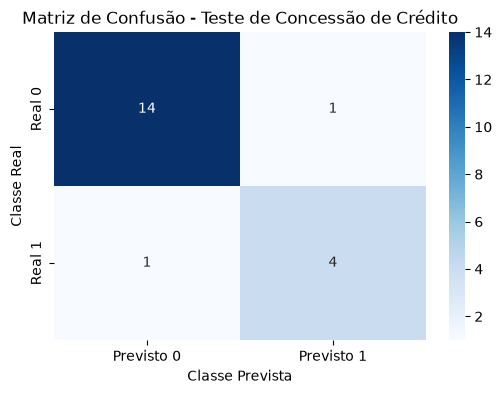

In [5]:
# Cálculo Prático das Métricas de Classificação e Matriz de Confusão em Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display no Github
from IPython.display import display

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Simulação de previsões de probabilidade para 20 proponentes de teste
np.random.seed(42)
y_teste_real = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
y_probabilidades = np.array([0.05, 0.12, 0.18, 0.08, 0.22, 0.15, 0.02, 0.35, 0.65, 0.10, 0.28, 0.14, 0.09, 0.04, 0.11, 0.88, 0.92, 0.75, 0.42, 0.81])

# Definição do Limiar Padrão de Decisão (Threshold = 0.50)
y_preditos = (y_probabilidades >= 0.50).astype(int)

# Cálculo do relatório e da matriz
report = classification_report(y_teste_real, y_preditos, target_names=['Adimplente (0)', 'Inadimplente (1)'])
matriz_conf = confusion_matrix(y_teste_real, y_preditos)
auc_score = roc_auc_score(y_teste_real, y_probabilidades)

print("--- RELATÓRIO DE DESEMPENHO TÉCNICO ---")
print(report)
print(f"Área Sob a Curva ROC (ROC-AUC): {auc_score:.4f}\n")

# Visualização da Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', xticklabels=['Previsto 0', 'Previsto 1'], yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de Confusão - Teste de Concessão de Crédito')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()


---
## 3. Distribuições Estatísticas e Geração de Dados com `np.random`

Para entender o comportamento das variáveis do dataset, analisamos as distribuições de probabilidade utilizadas na geração sintética da base.

![Distribuições Estatísticas](images/normal_poisson_distributions_pt.jpg)

### A) Distribuição Normal / Gaussiana (`np.random.normal`)
Modelos contínuos simétricos em formato de sino, definidos pela média $\mu$ e desvio padrão $\sigma$:
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

#### Regra Empírica (68% - 95% - 99.7%):
- **$68.27\%$** das observações estão entre $\mu - 1\sigma$ e $\mu + 1\sigma$.
- **$95.45\%$** das observações estão entre $\mu - 2\sigma$ e $\mu + 2\sigma$.
- **$99.73\%$** das observações estão entre $\mu - 3\sigma$ e $\mu + 3\sigma$.

### B) Distribuição de Poisson (`np.random.poisson`)
Modelos discretos que contam o número de ocorrências de um evento em um intervalo fixo com taxa média de ocorrência $\lambda$:
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

- **Consultas recentes ao CPF**: Poisson com $\lambda = 2.3$ consultas/trimestre.
- **Histórico de atrasos em 12m**: Poisson com $\lambda = 0.8$ ocorrências/ano.

### C) Outras Funções do Módulo `np.random`:
- `np.random.choice()`: Seleção aleatória em listas de categorias com pesos probabilísticos personalizados.
- `np.random.exponential()`: Distribuição de renda assimétrica com cauda longa à direita.
- `np.clip()`: Truncamento de valores fora do intervalo regulatório (ex: Score Serasa travado entre 150 e 990).


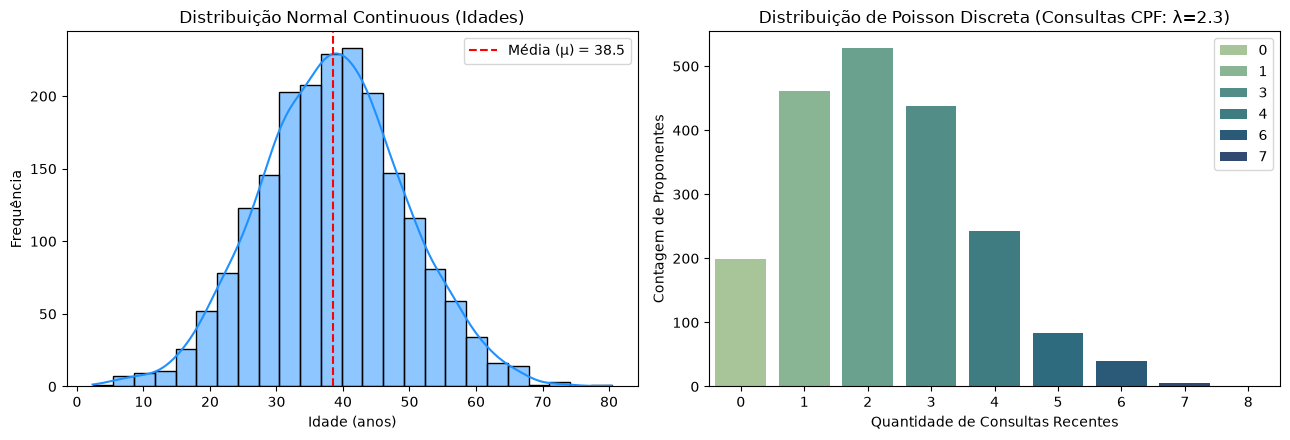

In [6]:
# Simulação e Comparação Gráfica entre Distribuição Normal e Poisson
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_amostras = 2000

# Gerando dados fictícios
idades_normal = np.random.normal(loc=38.0, scale=11.0, size=n_amostras)
consultas_poisson = np.random.poisson(lam=2.3, size=n_amostras)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 1: Distribuição Normal de Idades
sns.histplot(idades_normal, kde=True, ax=axes[0], color='dodgerblue', bins=25)
axes[0].axvline(np.mean(idades_normal), color='red', linestyle='--', label=f'Média (µ) = {np.mean(idades_normal):.1f}')
axes[0].set_title('Distribuição Normal Continuous (Idades)')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Gráfico 2: Distribuição de Poisson de Consultas
sns.countplot(x=consultas_poisson, hue=consultas_poisson, ax=axes[1], palette='crest')
axes[1].set_title('Distribuição de Poisson Discreta (Consultas CPF: λ=2.3)')
axes[1].set_xlabel('Quantidade de Consultas Recentes')
axes[1].set_ylabel('Contagem de Proponentes')

plt.tight_layout()
plt.show()


---
## 4. Anatomia do Dataset de Crédito Bruto (`df_raw`)

Abaixo, geramos e inspecionamos o dataset bruto completo contendo 3.000 propostas de crédito com ruidos reais de produção.


In [7]:
# Gerando a base sintética com ruidos intencionais
np.random.seed(42)
n_amostras = 3000

vinculos_brutos = ['CLT', ' CLT ', 'clt', 'Autonomo', 'AUTONOMO', 'PJ', 'Servidor_Publico', 'Estudante']
vinculos = np.random.choice(vinculos_brutos, size=n_amostras, p=[0.35, 0.10, 0.05, 0.20, 0.05, 0.12, 0.08, 0.05])
estados_civis = np.random.choice(['Solteiro', 'Casado', 'Divorciado', 'Viuvo'], size=n_amostras, p=[0.45, 0.40, 0.12, 0.03])
escolaridades = np.random.choice(['Medio', 'Superior', 'Pos_Graduacao', 'Fundamental'], size=n_amostras, p=[0.40, 0.42, 0.12, 0.06])

idade = np.random.normal(loc=38.0, scale=11.0, size=n_amostras)
renda_mensal = np.random.exponential(scale=4200.0, size=n_amostras) + 1400.0
valor_solicitado = np.random.uniform(2000.0, 35000.0, size=n_amostras)
numero_parcelas = np.random.choice([12, 24, 36, 48, 60], size=n_amostras, p=[0.2, 0.3, 0.25, 0.15, 0.10])
score_serasa = np.clip(np.random.normal(loc=620.0, scale=140.0, size=n_amostras), 150.0, 990.0)
num_consultas_recentes = np.random.poisson(lam=2.3, size=n_amostras)
atrasos_ultimos_12m = np.random.poisson(lam=0.8, size=n_amostras)

# Ruidos
idade[np.random.choice(n_amostras, size=4, replace=False)] = 999.0
idade[np.random.choice(n_amostras, size=4, replace=False)] = -15.0
renda_mensal[np.random.choice(n_amostras, size=6, replace=False)] = 999999.0
renda_mensal[np.random.choice(n_amostras, size=int(0.06 * n_amostras), replace=False)] = np.nan
score_serasa[np.random.choice(n_amostras, size=int(0.05 * n_amostras), replace=False)] = np.nan

parcela_mensal = valor_solicitado / numero_parcelas
comprometimento = parcela_mensal / (renda_mensal + 1e-5)
stress = (comprometimento * 4.5) + (atrasos_ultimos_12m * 0.85) + (num_consultas_recentes * 0.25) - ((score_serasa - 600.0) / 130.0) - ((renda_mensal - 4000.0) / 3500.0) + np.random.normal(0.0, 0.9, size=n_amostras)
prob_inad = 1.0 / (1.0 + np.exp(-(stress - 1.8)))
inadimplente = (np.random.rand(n_amostras) < prob_inad).astype(int)

df_raw = pd.DataFrame({
    'proponente_id': [f"PROP-{10000 + i}" for i in range(n_amostras)],
    'idade': np.round(idade, 1),
    'tipo_vinculo': vinculos,
    'estado_civil': estados_civis,
    'escolaridade': escolaridades,
    'renda_mensal': np.round(renda_mensal, 2),
    'valor_solicitado': np.round(valor_solicitado, 2),
    'numero_parcelas': numero_parcelas,
    'score_serasa': np.round(score_serasa, 1),
    'num_consultas_recentes': num_consultas_recentes,
    'atrasos_ultimos_12m': atrasos_ultimos_12m,
    'ruido_estocastico': np.round(np.random.normal(0.0, 50.0, size=n_amostras), 2),
    'numero_da_sorte_app': np.random.randint(1000, 9999, size=n_amostras),
    'ip_origem_hash': [f"IP-{hex(np.random.randint(100000, 999999))[2:].upper()}" for _ in range(n_amostras)],
    'inadimplente': inadimplente
})

print("Shape do dataset bruto:", df_raw.shape)
display(df_raw.head())


Shape do dataset bruto: (3000, 15)


,proponente_id,idade,tipo_vinculo,estado_civil,escolaridade,renda_mensal,valor_solicitado,numero_parcelas,score_serasa,num_consultas_recentes,atrasos_ultimos_12m,ruido_estocastico,numero_da_sorte_app,ip_origem_hash,inadimplente
0,PROP-10000,38.6,CLT,Casado,Superior,6712.15,14246.95,36,558.4,2,1,6.18,6065,IP-6C5C3,0
1,PROP-10001,47.5,Estudante,Casado,Medio,5368.84,5190.76,48,870.5,1,0,-35.96,2952,IP-C8AB0,0
2,PROP-10002,32.8,AUTONOMO,Solteiro,Pos_Graduacao,2225.99,9473.20,36,621.8,3,0,15.62,2156,IP-E8425,1
3,PROP-10003,56.4,Autonomo,Casado,Superior,3381.73,31624.27,36,577.0,1,1,-14.38,5055,IP-B3634,1
4,PROP-10004,21.9,CLT,Casado,Medio,4049.39,34329.83,24,622.4,1,1,51.27,8441,IP-779C5,0


In [11]:
df_raw.to_csv('../materiais/CRISP_DM_Random_Forest_Credito.csv', index=False)
print("df_raw salvo como CRISP_DM_Random_Forest_Credito.csv")

df_raw salvo como CRISP_DM_Random_Forest_Credito.csv


In [8]:
# Inspeção de Nulos e Desbalanceamento de Classes
print("--- Valores Ausentes (NaNs) Por Coluna ---")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print("\n--- Proporção da Variável Alvo 'inadimplente' ---")
print(df_raw['inadimplente'].value_counts(normalize=True) * 100)


--- Valores Ausentes (NaNs) Por Coluna ---
renda_mensal    180
score_serasa    150
dtype: int64

--- Proporção da Variável Alvo 'inadimplente' ---
inadimplente
0    58.533333
1    41.466667
Name: proportion, dtype: float64


---
## 5. Exercícios de Fixação

1. Explique a diferença conceitual entre **Precisão** e **Recall**. Em qual situação de negócios a Precisão seria mais importante que o Recall?
2. Em uma distribuição Normal de pontuação de score Serasa com $\mu = 620$ e $\sigma = 140$, qual é o intervalo de pontuação que engloba $95\%$ de todos os proponentes?
3. O que aconteceria com os cálculos de desvio padrão se não tratássemos idades iguais a `999.0` na base?
4. Qual a diferença principal entre variáveis contínuas (geradas por `np.random.normal`) e variáveis de contagem discreta (geradas por `np.random.poisson`)?
